# Technical Analysis and Narrative: Germany Energy Forecasting Prototype

This documentation provides the technical rationale behind the observed correlations within the German power market (2020–2026). By integrating high-resolution Quarter-hourly (QH) load data with multi-variable weather stream

## 1. Data Ingestion and Granularity: The QH Advantage

The transition from standard UK Non-half-hourly (NHH) forecasting to the German Quarter-hourly (QH - Every 15 mins) model allows for the capture of steep "ramp-up" and "ramp-down" periods.

**Technical Context:** High-resolution granularity is essential for managing the imbalance settlement process. Deviations from contracted positions must be settled at the System Buy/Sell Price. By analyzing QH data, we identify intra-hour volatility that hourly models smooth over, directly reducing the risk of imbalance charges.

**Commercial Logic:** This precision supports the "Smartest Short" strategy by allowing traders to optimize positions in 15-minute Intraday blocks rather than broader hourly aggregates.

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import openmeteo_requests
from datetime import datetime
import requests_cache
from retry_requests import retry



CSV_FILE = "Actual_consumption_202001010000_202601010000_Quarterhour.csv"

def smard_csv(file_path):
    # Semicolon separator, comma = thousands, dot = decimal
    df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)

    df['datetime'] = pd.to_datetime(df['Start date'])
    df = df.set_index('datetime') # to change 0, 1, 2, index in to date itself
    
    load_col = 'grid load [MWh] Original resolutions'
    df = df[[load_col]].rename(columns={load_col: 'load_mwh'}) 
    
    return df

df_load = smard_csv(CSV_FILE)

df = df_load

df = df.dropna()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour
df['is_weekend'] = df.index.weekday >= 5
df['day_of_year'] = df.index.dayofyear

print(f"Data processed: {df.index.min()} to {df.index.max()}")
df.tail()

/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_99431/3513955949.py:15: DtypeWarning: Columns (0: Residual load [MWh] Original resolutions) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)
/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_99431/3513955949.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df['Start date'])


Data processed: 2020-01-01 00:00:00 to 2025-12-31 23:45:00


,load_mwh,year,month,hour,is_weekend,day_of_year
datetime,,,,,,
2025-12-31 22:45:00,12092.33,2025,12,22,False,365
2025-12-31 23:00:00,11954.01,2025,12,23,False,365
2025-12-31 23:15:00,11905.14,2025,12,23,False,365
2025-12-31 23:30:00,11818.62,2025,12,23,False,365
2025-12-31 23:45:00,11756.82,2025,12,23,False,365


In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

CSV_FILE = "Actual_consumption_202001010000_202601010000_Quarterhour.csv"

def smard_csv(file_path):
    # Semicolon separator, comma = thousands, dot = decimal
    df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)
    return df
df_load = smard_csv(CSV_FILE)

df = df_load
df.head(100)

/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_99431/2698042922.py:9: DtypeWarning: Columns (0: Residual load [MWh] Original resolutions) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)


,Start date,End date,grid load [MWh] Original resolutions,Grid load incl. hydro pumped storage [MWh] Original resolutions,Hydro pumped storage [MWh] Original resolutions,Residual load [MWh] Original resolutions
0,"Jan 1, 2020 12:00 AM","Jan 1, 2020 12:15 AM",10970.50,11019.25,48.75,"9,363.00"
1,"Jan 1, 2020 12:15 AM","Jan 1, 2020 12:30 AM",10910.00,10966.25,56.25,"9,303.50"
2,"Jan 1, 2020 12:30 AM","Jan 1, 2020 12:45 AM",10832.75,10904.25,71.50,"9,165.50"
3,"Jan 1, 2020 12:45 AM","Jan 1, 2020 1:00 AM",10787.25,10886.50,99.25,"9,058.25"
4,"Jan 1, 2020 1:00 AM","Jan 1, 2020 1:15 AM",10754.25,10825.50,71.25,"9,003.00"
...,...,...,...,...,...,...
95,"Jan 1, 2020 11:45 PM","Jan 2, 2020 12:00 AM",11099.00,11180.25,81.25,"8,018.75"
96,"Jan 2, 2020 12:00 AM","Jan 2, 2020 12:15 AM",11087.50,11174.75,87.25,"7,993.25"
97,"Jan 2, 2020 12:15 AM","Jan 2, 2020 12:30 AM",11045.25,11226.50,181.25,"7,933.25"
98,"Jan 2, 2020 12:30 AM","Jan 2, 2020 12:45 AM",10991.75,11323.50,331.75,"7,896.75"


## 2. Average load profile

The daily load profile analysis highlights a dual-peak structure during the work week (Standard Load Profile — SLP).

**Technical Analysis:** The 8:00 AM peak represents the simultaneous activation of industrial processes and commercial lighting/HVAC. The gap between the Weekday and Weekend curves quantifies the Industrial Baseload Component.  

**The Findings:** During weekends, the load curve is not only lower but exhibits a different shape, characterized by a slower morning ramp. This suggests that residential demand (synthetic H0 profiles) is less sensitive to fixed start-times than the industrial RLM (Registering Load Measurement) demand.  

### Load Categorization
**Baseload**: The constant, non-varying minimum demand observed between 02:00 and 04:00 AM. This is the "floor" of the grid, driven by 24/7 industrial processes and essential infrastructure. 

**Peak**: The high-demand window (typically 08:00 to 20:00) where industrial RLM demand and commercial SLP demand coincide.  

**Off-Peak**: Periods of lower demand, primarily nights and weekends, where the "Industrial Baseload Component" is absent.  

### Anatomy of the Average Load Profile
**The Industrial Pulse (RLM)**: The sharp gradient at 08:00 AM is the technical signature of RLM (Registering Load Measurement) customers. These are large-scale consumers whose demand is metered in real-time. The steepness of this ramp requires high load-following capacity from conventional and flexible assets.  

**The Consumer Pulse (SLP)**: The secondary evening peak represents the SLP (Standard Load Profile), specifically the H0 (Household) and G0 (Small Business) profiles.  


### Grid Stability and Frequency Reserves (aFRR/aFFR)
Because electricity must be generated and consumed instantaneously, the 4 German TSOs (50Hertz, Amprion, TenneT, and TransnetBW) must manage any deviation between our forecasted load and actual QH consumption.  

**aFRR (Automatic Frequency Restoration Reserve)**: When the actual load deviates from our 15-minute schedule, the TSO automatically activates aFRR to restore the frequency to 50Hz.  

**Commercial Strategy**: By understanding the "Demand Variation" in our plots, we can minimize our exposure to aFRR activation costs. Accurate forecasting at the "Commercial Heart" ensures we stay within our Balancing Group equilibrium.  

### Virtual Power Plants (VPP) and Flexibility
**DGs (Distributed Generators)** connected to the distribution grid has enabled the deployment of Virtual Power Plants (VPP).  
VPP Operation: A VPP aggregates small assets (Solar, Wind, Battery) to act as a single large-scale flexible unit.  

**Technical Utility**: During the "Weekend Dip" identified in our findings, a VPP can provide negative control power (reducing generation or increasing consumption) to the distribution grid, monetizing the flexibility of assets when industrial demand is low.  

### Long-Term Hedging: PPAs and Solar Integration
To stabilize long-term procurement costs, we utilize PPAs (Power Purchase Agreements).  
**Solar PPA Alignment**: Solar generation naturally correlates with the mid-day portion of the Peak block. By signing a Solar PPA, we hedge the volume of the mid-day load spike seen in our daily profiles.  

**Volume Customization**: "How much you want to" procure depends on the Residual Load calculation. We use the 5-year average to determine the "P90" level of solar generation needed to cover the peak without over-procuring during the low-demand "Deep Dips" of the summer months.  

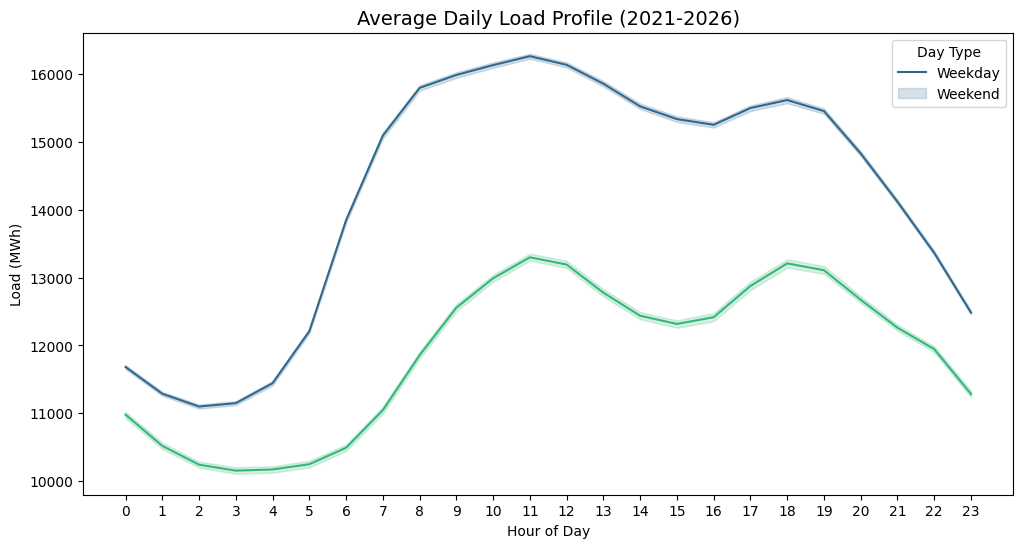

'\n4-8, climbing from ~11,100 MWh to ~15,800 MWh\nPeak demand hits around hour 11 (11 AM) at approximately 16,500 MWh\nEvening decline begins after hour 19, dropping sharply to ~12,600 MWh by hour 23\n'

In [6]:
plt.figure(figsize=(12, 6))
df_recent = df[df['year'] >= 2021]

sns.lineplot(data=df_recent, x='hour', y='load_mwh', hue='is_weekend', palette="viridis")
plt.title("Average Daily Load Profile (2021-2026)", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Load (MWh)")
plt.xticks(range(24))
plt.legend(title="Day Type", labels=["Weekday", "Weekend"])
plt.show()

"""
4-8, climbing from ~11,100 MWh to ~15,800 MWh
Peak demand hits around hour 11 (11 AM) at approximately 16,500 MWh
Evening decline begins after hour 19, dropping sharply to ~12,600 MWh by hour 23


Off peak
Peak
Base load 
AFFR = automated frequence restore reserve
vpp = virtual power plant= dgs to distrubution grid 
Automated frequence reserce
PPA (power pruchansing agreement)
TSO = in germany 4
Solar PPA (how much you want to )

ntp_GjB02XYPNNQKuc919Jif
cm_app_ntp_id_4e723cf4376c420985f5c036aafc5537
ntp_delroyprithvi@gmail.com_test
FCR
aFRR
MFRR
"""


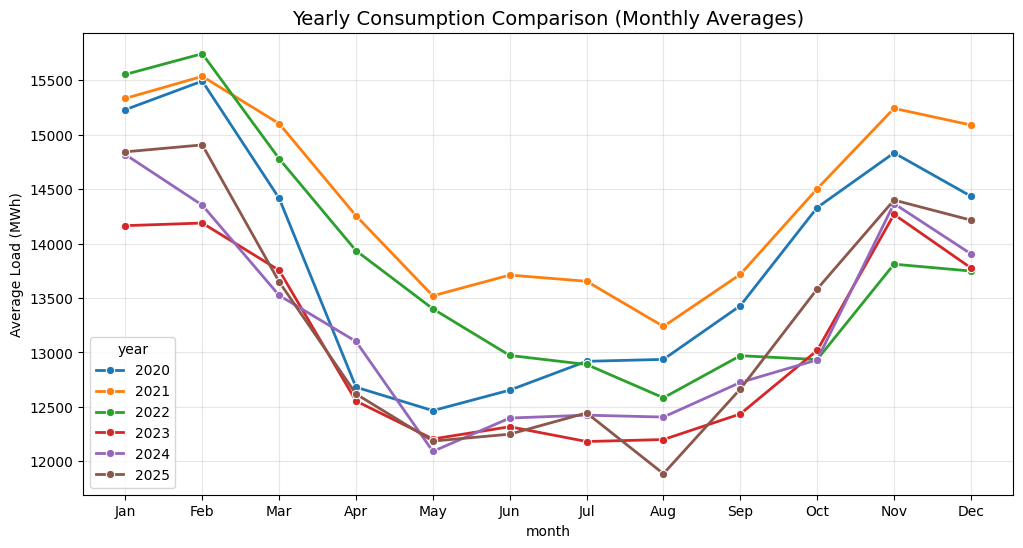

'\nEnergy use is highest in winter.\nIt drops sharply in spring.\nSummer has the lowest and most stable demand.\nConsumption rises again in autumn.\nBiggest jump = October and November.\n'

In [7]:
monthly = df[df['year'].between(2020, 2025)].groupby(['year', 'month'])['load_mwh'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x='month', y='load_mwh', hue='year', palette="tab10", marker='o', linewidth=2)
plt.title("Yearly Consumption Comparison (Monthly Averages)", fontsize=14)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.ylabel("Average Load (MWh)")
plt.grid(True, alpha=0.3)
plt.show()

'''
Energy use is highest in winter.
It drops sharply in spring.
Summer has the lowest and most stable demand.
Consumption rises again in autumn.
Biggest jump = October and November.
'''


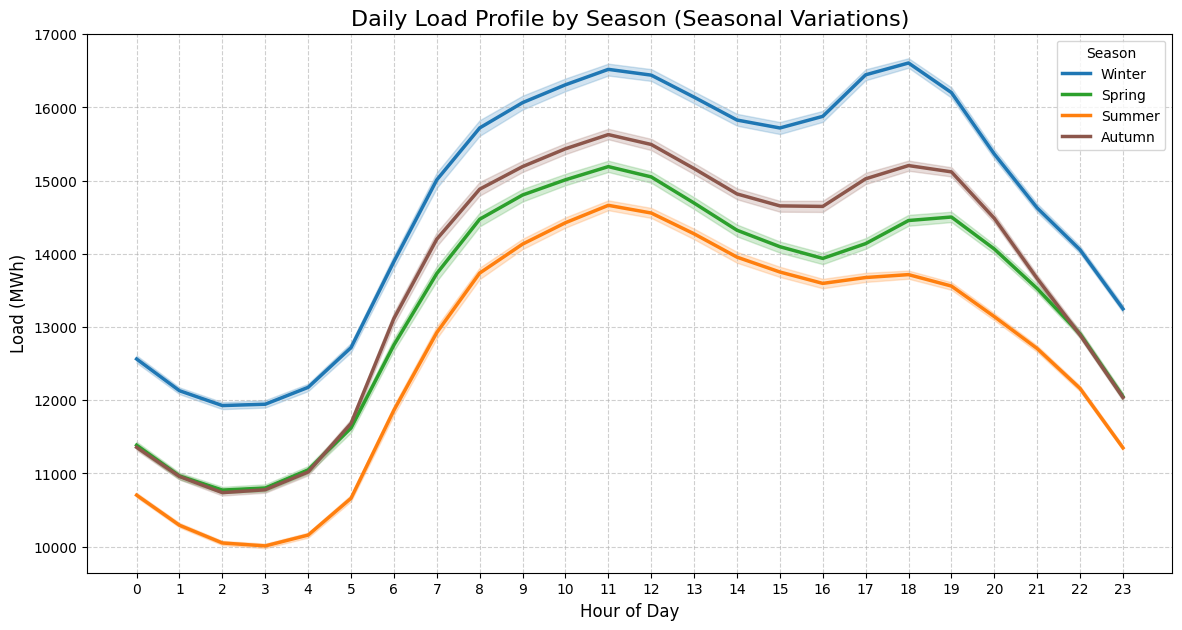

Average Load by Season:
season
Winter    14731.154349
Spring    13347.749023
Summer    12669.779323
Autumn    13674.001922
Name: load_mwh, dtype: float64


In [12]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else: # 9 10 11
        return 'Autumn'

df['season'] = df['month'].apply(get_season)
plt.figure(figsize=(14, 7)) # width and height

season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = {"Winter": "#1f77b4", "Spring": "#2ca02c", "Summer": "#ff7f0e", "Autumn": "#8c564b"}

sns.lineplot(
    data=df, 
    x='hour', 
    y='load_mwh', 
    hue='season', 
    hue_order=season_order,
    palette=season_colors,
    linewidth=2.5
)

plt.title("Daily Load Profile by Season (Seasonal Variations)", fontsize=16)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Load (MWh)", fontsize=12)
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Season", fontsize=10)

plt.show()

# average load per season for comparison
print("Average Load by Season:")
print(df.groupby('season')['load_mwh'].mean().reindex(season_order))

**COVID-19 Impact (2020–2021):** "Flattening of the Peak" = Lockdowns reduced the magnitude of the 8:00 AM industrial spike. Technically, this represents a shift from commercial-centric consumption to a more distributed, residential-weighted profile.

**Russia–Ukraine War & Energy Crisis (2022–Present):** Post-February 2022 data shows evidence of "Demand Destruction." High wholesale prices (influenced by the Gas Merit Order) triggered energy-saving measures across the German manufacturing sector.

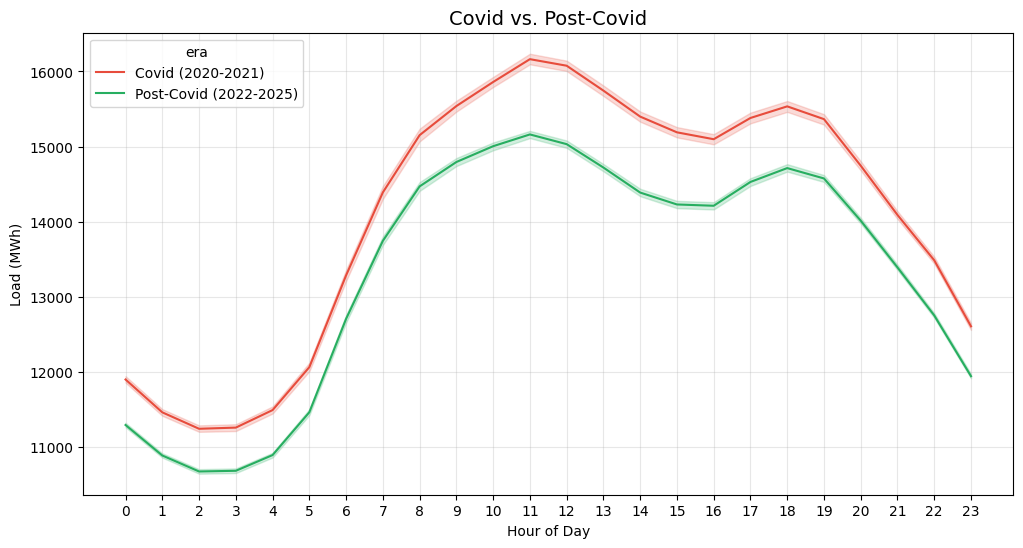

Average Load Comparison:
era
Covid (2020-2021)         14106.793997
Post-Covid (2022-2025)    13347.009928
Name: load_mwh, dtype: float64


In [15]:
def categorize_era(year):
    if year in [2020, 2021]:
        return 'Covid (2020-2021)'
    elif year >= 2022:
        return 'Post-Covid (2022-2025)'
    else:
        return 'Pre-Covid' # not data for

df['era'] = df['year'].apply(categorize_era)

# plot the hourly profiles
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='hour', y='load_mwh', hue='era', palette=['#e74c3c', '#27ae60'])

plt.title("Covid vs. Post-Covid", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Load (MWh)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.show()

# statistics
stats = df.groupby('era')['load_mwh'].mean()
print("Average Load Comparison:")
print(stats)

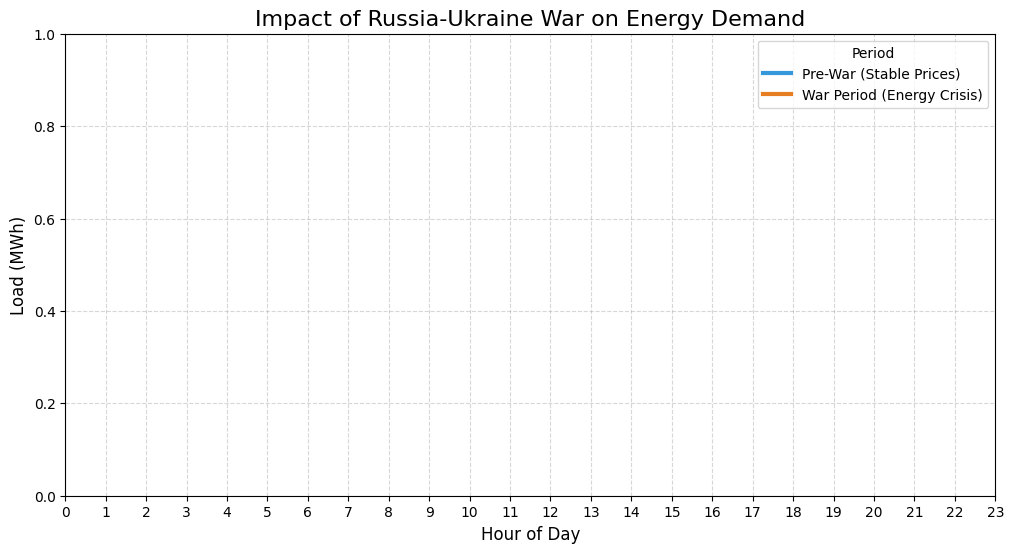

KeyError: 'Pre-War (Stable Prices)'

In [22]:
war_start_date = pd.Timestamp('2022-02-24')

df['war_period'] = df.index.map(lambda x: 'Pre-War' if x < war_start_date else 'War Period')

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df, 
    x='hour', 
    y='load_mwh', 
    hue='war_period', 
    hue_order=['Pre-War (Stable Prices)', 'War Period (Energy Crisis)'],
    palette=['#3498db', '#e67e22'],
    linewidth=3
)

plt.title("Impact of Russia-Ukraine War on Energy Demand", fontsize=16)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Load (MWh)", fontsize=12)
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Period")

plt.show()

stats = df.groupby('war_period')['load_mwh'].mean()
pre_war = stats['Pre-War (Stable Prices)']
post_war = stats['War Period (Energy Crisis)']
drop_pct = ((pre_war - post_war) / pre_war) * 100

print(f"Average Load Pre-War:  {pre_war:.2f} MWh")
print(f"Average Load Post-War: {post_war:.2f} MWh")
print(f"Total Consumption Drop: {drop_pct:.2f}%")

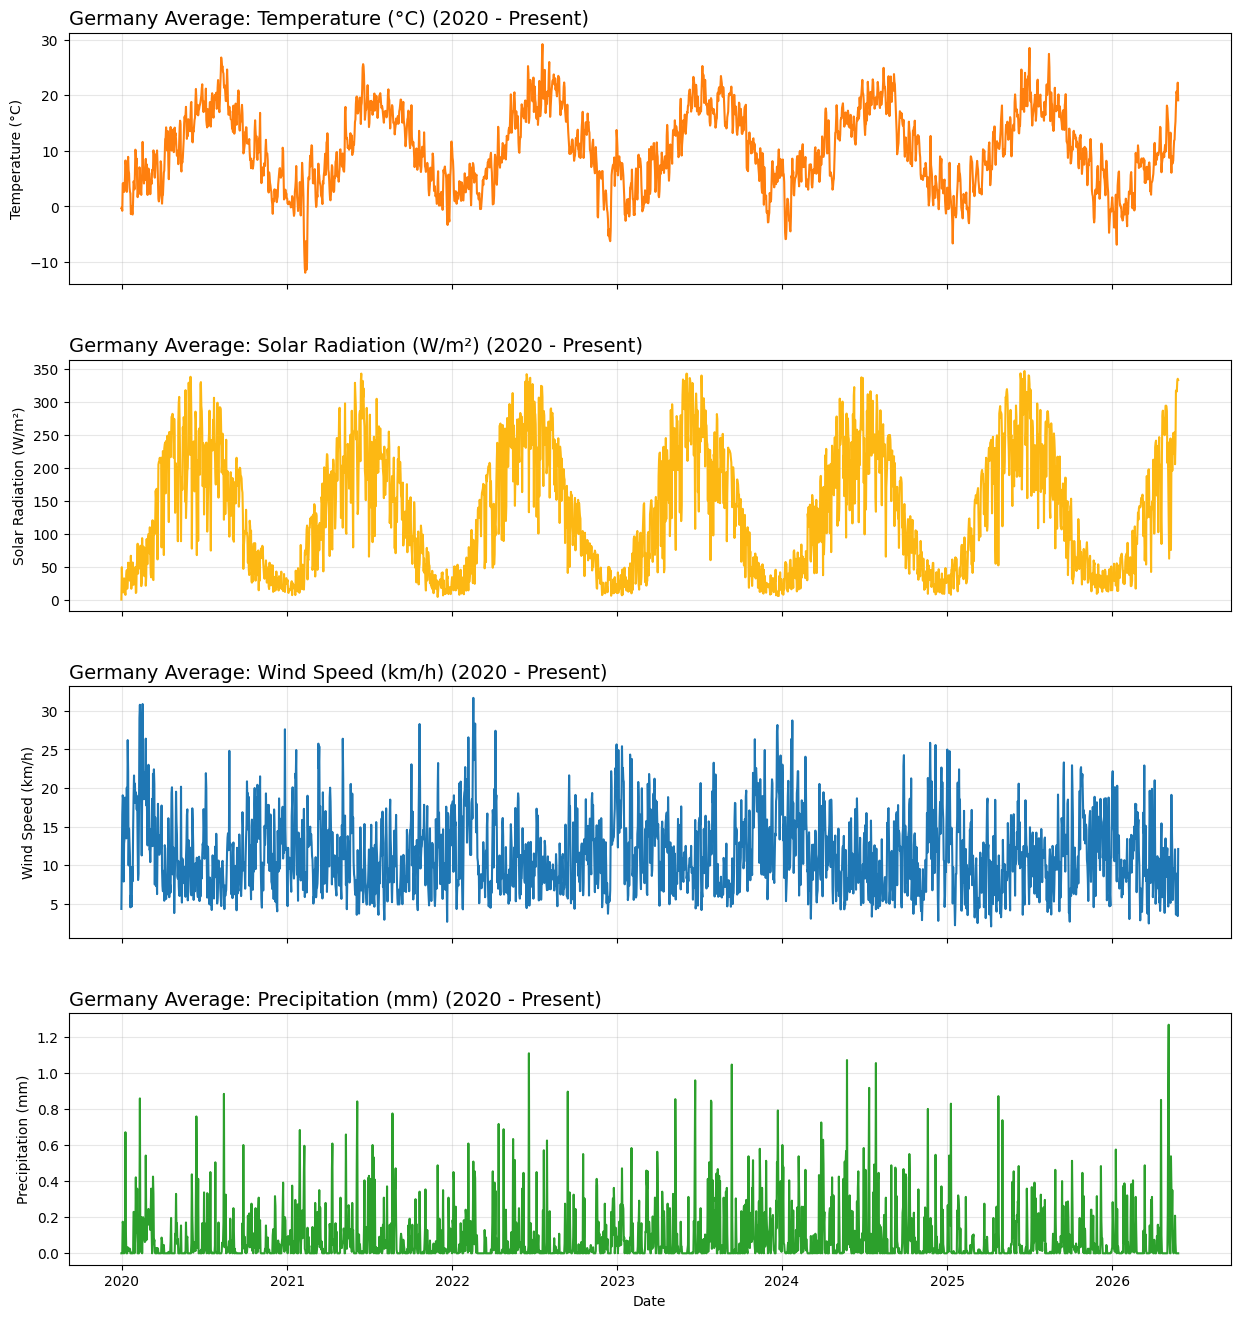

In [27]:

def fetch_and_plot_weather():
    openmeteo = openmeteo_requests.Client()

    # 2. Kassel (Center of Germany)
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 51.3127,
        "longitude": 9.4797,
        "start_date": "2020-01-01",
        "end_date": datetime.now().strftime('%Y-%m-%d'),
        "hourly": ["temperature_2m", "shortwave_radiation", "wind_speed_10m", "precipitation"],
        "timezone": "Europe/Berlin"
    }

    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]

    hourly = response.Hourly()
    
    temp = hourly.Variables(0).ValuesAsNumpy()
    solar = hourly.Variables(1).ValuesAsNumpy()
    wind = hourly.Variables(2).ValuesAsNumpy()
    precip = hourly.Variables(3).ValuesAsNumpy()

    start_dt = pd.to_datetime(hourly.Time(), unit="s", utc=True)
    time_index = pd.date_range(
        start=start_dt,
        periods=len(temp),
        freq=pd.Timedelta(seconds=hourly.Interval())
    )

    df_weather = pd.DataFrame({
        "Temperature (°C)": temp,
        "Solar Radiation (W/m²)": solar,
        "Wind Speed (km/h)": wind,
        "Precipitation (mm)": precip
    }, index=time_index)

    df_weather.index = df_weather.index.tz_convert("Europe/Berlin").tz_localize(None)

    df_daily = df_weather.resample('D').mean()

    # 6. Create 4-Panel Plot
    fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)
    plt.subplots_adjust(hspace=0.3)

    colors = ['#ff7f0e', '#fdb813', '#1f77b4', '#2ca02c']
    columns = ["Temperature (°C)", "Solar Radiation (W/m²)", "Wind Speed (km/h)", "Precipitation (mm)"]

    for i, col in enumerate(columns):
        axes[i].plot(df_daily.index, df_daily[col], color=colors[i], linewidth=1.5)
        axes[i].set_title(f"Germany Average: {col} (2020 - Present)", fontsize=14, loc='left')
        axes[i].set_ylabel(col)
        axes[i].grid(True, alpha=0.3)

    plt.xlabel("Date")
    plt.show()

# Execute
fetch_and_plot_weather()
# adding monthly graphs = weather 
# merge = weather data and load data for a day

In [33]:
CSV_FILE = "Actual_consumption_202001010000_202601010000_Quarterhour.csv"

def smard_csv(file_path):
    # Semicolon separator, comma = thousands, dot = decimal
    df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)
    return df
df_load = smard_csv(CSV_FILE)

df = df_load
df.head(100)
# generation and load profile


/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_99431/2962108178.py:5: DtypeWarning: Columns (0: Residual load [MWh] Original resolutions) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)


,Start date,End date,grid load [MWh] Original resolutions,Grid load incl. hydro pumped storage [MWh] Original resolutions,Hydro pumped storage [MWh] Original resolutions,Residual load [MWh] Original resolutions
0,"Jan 1, 2020 12:00 AM","Jan 1, 2020 12:15 AM",10970.50,11019.25,48.75,"9,363.00"
1,"Jan 1, 2020 12:15 AM","Jan 1, 2020 12:30 AM",10910.00,10966.25,56.25,"9,303.50"
2,"Jan 1, 2020 12:30 AM","Jan 1, 2020 12:45 AM",10832.75,10904.25,71.50,"9,165.50"
3,"Jan 1, 2020 12:45 AM","Jan 1, 2020 1:00 AM",10787.25,10886.50,99.25,"9,058.25"
4,"Jan 1, 2020 1:00 AM","Jan 1, 2020 1:15 AM",10754.25,10825.50,71.25,"9,003.00"
...,...,...,...,...,...,...
95,"Jan 1, 2020 11:45 PM","Jan 2, 2020 12:00 AM",11099.00,11180.25,81.25,"8,018.75"
96,"Jan 2, 2020 12:00 AM","Jan 2, 2020 12:15 AM",11087.50,11174.75,87.25,"7,993.25"
97,"Jan 2, 2020 12:15 AM","Jan 2, 2020 12:30 AM",11045.25,11226.50,181.25,"7,933.25"
98,"Jan 2, 2020 12:30 AM","Jan 2, 2020 12:45 AM",10991.75,11323.50,331.75,"7,896.75"


In [34]:
CSV_FILE = "Gro_handelspreise_202001010000_202601010000_Viertelstunde.csv"

def smard_csv(file_path):
    # Semicolon separator, comma = thousands, dot = decimal
    df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)
    return df
df_load = smard_csv(CSV_FILE)

df = df_load
df.head(100)
# load profile and market price


/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_99431/2519045303.py:5: DtypeWarning: Columns (0: Frankreich [€/MWh] Originalauflösungen, 1: Slowenien [€/MWh] Originalauflösungen, 2: Ungarn [€/MWh] Originalauflösungen) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=';', thousands=',', decimal='.', index_col=False)


,Datum von,Datum bis,Deutschland/Luxemburg [€/MWh] Originalauflösungen,∅ Anrainer DE/LU [€/MWh] Originalauflösungen,Belgien [€/MWh] Originalauflösungen,Dänemark 1 [€/MWh] Originalauflösungen,Dänemark 2 [€/MWh] Originalauflösungen,Frankreich [€/MWh] Originalauflösungen,Niederlande [€/MWh] Originalauflösungen,Norwegen 2 [€/MWh] Originalauflösungen,Österreich [€/MWh] Originalauflösungen,Polen [€/MWh] Originalauflösungen,Schweden 4 [€/MWh] Originalauflösungen,Schweiz [€/MWh] Originalauflösungen,Tschechien [€/MWh] Originalauflösungen,DE/AT/LU [€/MWh] Originalauflösungen,Italien (Nord) [€/MWh] Originalauflösungen,Slowenien [€/MWh] Originalauflösungen,Ungarn [€/MWh] Originalauflösungen
0,01.01.2020 00:00,01.01.2020 00:15,4188,3623,4188,3342,3342,4188,4188,3182,4188,3495,2878,3542,3320,-,4188,4188,3355
1,01.01.2020 00:15,01.01.2020 00:30,4188,3623,4188,3342,3342,4188,4188,3182,4188,3495,2878,3542,3320,-,4188,4188,3355
2,01.01.2020 00:30,01.01.2020 00:45,4188,3623,4188,3342,3342,4188,4188,3182,4188,3495,2878,3542,3320,-,4188,4188,3355
3,01.01.2020 00:45,01.01.2020 01:00,4188,3623,4188,3342,3342,4188,4188,3182,4188,3495,2878,3542,3320,-,4188,4188,3355
4,01.01.2020 01:00,01.01.2020 01:15,3860,3430,3860,3177,3177,3860,3860,3177,3860,3467,2845,3404,3040,-,3860,3860,3040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,01.01.2020 23:45,02.01.2020 00:00,3485,3250,3856,3061,3061,3669,3147,3061,3534,3530,2481,3185,3160,-,3669,3534,3160
96,02.01.2020 00:00,02.01.2020 00:15,3540,3135,3540,3078,3078,3540,3540,3078,3540,3331,1207,3357,3201,-,3540,3540,3201
97,02.01.2020 00:15,02.01.2020 00:30,3540,3135,3540,3078,3078,3540,3540,3078,3540,3331,1207,3357,3201,-,3540,3540,3201
98,02.01.2020 00:30,02.01.2020 00:45,3540,3135,3540,3078,3078,3540,3540,3078,3540,3331,1207,3357,3201,-,3540,3540,3201


Reading Load Data...


/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_99431/2285057086.py:11: DtypeWarning: Columns (0: Residual load [MWh] Original resolutions) have mixed types. Specify dtype option on import or set low_memory=False.
  df_l = pd.read_csv(LOAD_CSV, sep=';', thousands=',', decimal='.', index_col=False)
/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_99431/2285057086.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_l['datetime'] = pd.to_datetime(df_l['Start date'], dayfirst=True)


Reading Price Data...


/var/folders/hh/bg0bd4m54q5f6g46vd2jw09w0000gn/T/ipykernel_99431/2285057086.py:24: DtypeWarning: Columns (0: Frankreich [€/MWh] Originalauflösungen, 1: Slowenien [€/MWh] Originalauflösungen, 2: Ungarn [€/MWh] Originalauflösungen) have mixed types. Specify dtype option on import or set low_memory=False.
  df_p = pd.read_csv(PRICE_CSV, sep=';', thousands=',', decimal='.', index_col=False)


Fetching Weather Data...
Merging all datasets...
Plotting complete for 2023-05-21.


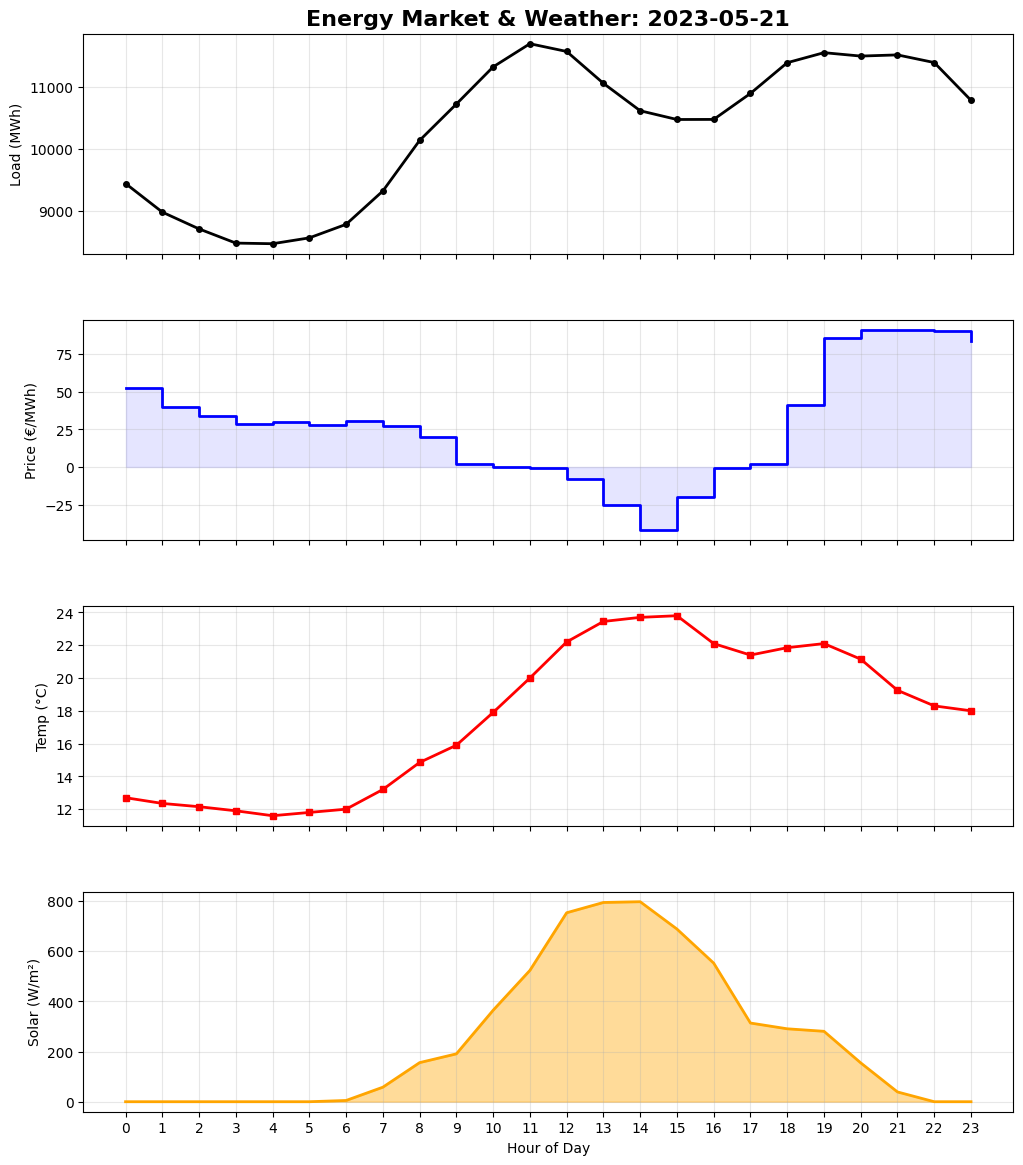

In [50]:
LOAD_CSV = "Actual_consumption_202001010000_202601010000_Quarterhour.csv"
PRICE_CSV = "Gro_handelspreise_202001010000_202601010000_Viertelstunde.csv"
DATE_TO_PLOT = "2023-05-21"  # <--- CHANGE THIS TO ANY DAY YOU WANT

# ==========================================
# 2. DATA PROCESSING FUNCTION
# ==========================================
def get_merged_data():
    # --- A. Process Load Data ---
    print("Reading Load Data...")
    df_l = pd.read_csv(LOAD_CSV, sep=';', thousands=',', decimal='.', index_col=False)
    df_l.columns = df_l.columns.str.strip() # Clean hidden spaces
    
    # Handle European Date Format
    df_l['datetime'] = pd.to_datetime(df_l['Start date'], dayfirst=True)
    df_l = df_l.set_index('datetime')
    
    load_col = 'grid load [MWh] Original resolutions'
    df_l = df_l[[load_col]].rename(columns={load_col: 'load_mwh'})
    df_l = df_l.resample('h').mean() # Downsample 15min -> 1hour

    # --- B. Process Price Data ---
    print("Reading Price Data...")
    df_p = pd.read_csv(PRICE_CSV, sep=';', thousands=',', decimal='.', index_col=False)
    df_p.columns = df_p.columns.str.strip()
    
    df_p['datetime'] = pd.to_datetime(df_p['Datum von'], dayfirst=True)
    df_p = df_p.set_index('datetime')
    
    price_col = 'Deutschland/Luxemburg [€/MWh] Originalauflösungen'
    # Convert to numeric and scale (4188 -> 41.88)
    df_p['price_eur'] = pd.to_numeric(df_p[price_col], errors='coerce') / 100.0
    df_p = df_p[['price_eur']].resample('h').mean()

    # --- C. Fetch Weather Data via API ---
    print("Fetching Weather Data...")
    cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
    retry_session = retry(cache_session, retries=5)
    openmeteo = openmeteo_requests.Client(session=retry_session)
    
    # Use the date range from your files
    start_date = df_l.index.min().strftime('%Y-%m-%d')
    end_date = df_l.index.max().strftime('%Y-%m-%d')
    
    params = {
        "latitude": 51.3127, "longitude": 9.4797, # Kassel (Center of DE)
        "start_date": start_date, "end_date": end_date,
        "hourly": ["temperature_2m", "shortwave_radiation"],
        "timezone": "Europe/Berlin"
    }
    
    responses = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)
    h_api = responses[0].Hourly()
    
    time_idx = pd.date_range(
        start=pd.to_datetime(h_api.Time(), unit="s", utc=True), 
        periods=len(h_api.Variables(0).ValuesAsNumpy()), 
        freq='h'
    )
    
    df_w = pd.DataFrame({
        "temp": h_api.Variables(0).ValuesAsNumpy(),
        "solar": h_api.Variables(1).ValuesAsNumpy()
    }, index=time_idx)
    
    # Align timezones
    df_w.index = df_w.index.tz_convert("Europe/Berlin").tz_localize(None)

    # --- D. FINAL MERGE ---
    print("Merging all datasets...")
    df_final = pd.merge(df_l, df_p, left_index=True, right_index=True, how='inner')
    df_final = pd.merge(df_final, df_w, left_index=True, right_index=True, how='inner')
    
    return df_final

# ==========================================
# 3. PLOTTING FUNCTION
# ==========================================
def plot_full_analysis(df, target_date):
    try:
        day_data = df.loc[target_date]
    except KeyError:
        print(f"Error: Date {target_date} not found in the data range.")
        return

    if day_data.empty:
        print("No data available for this date.")
        return

    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
    plt.subplots_adjust(hspace=0.3)
    
    hours = day_data.index.hour

    # 1. Grid Load (MWh)
    axes[0].plot(hours, day_data['load_mwh'], color='black', lw=2, marker='o', markersize=4)
    axes[0].set_ylabel("Load (MWh)")
    axes[0].set_title(f"Energy Market & Weather: {target_date}", fontsize=16, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    # 2. Market Price (€/MWh)
    # Using 'step' because prices change in blocks
    axes[1].step(hours, day_data['price_eur'], color='blue', lw=2, where='post')
    axes[1].fill_between(hours, day_data['price_eur'], step="post", color='blue', alpha=0.1)
    axes[1].set_ylabel("Price (€/MWh)")
    axes[1].grid(True, alpha=0.3)

    # 3. Temperature (°C)
    axes[2].plot(hours, day_data['temp'], color='red', lw=2, marker='s', markersize=4)
    axes[2].set_ylabel("Temp (°C)")
    axes[2].grid(True, alpha=0.3)

    # 4. Solar Radiation (W/m²)
    axes[3].fill_between(hours, day_data['solar'], color='orange', alpha=0.4)
    axes[3].plot(hours, day_data['solar'], color='orange', lw=2)
    axes[3].set_ylabel("Solar (W/m²)")
    axes[3].set_xlabel("Hour of Day")
    axes[3].grid(True, alpha=0.3)

    plt.xticks(range(0, 24))
    print(f"Plotting complete for {target_date}.")
    plt.show()

# ==========================================
# 4. RUN EVERYTHING
# ==========================================
df_all = get_merged_data()
plot_full_analysis(df_all, DATE_TO_PLOT)

In [52]:
CSV_FILE = "EC_EV_dataset.xlsx - Load.csv"

def smard_csv(file_path):

    df = pd.read_csv(file_path, sep=',', decimal='.', index_col=0)
    return df

df_load = smard_csv(CSV_FILE)

print(df_load.head())

          1         2         3         4         5         6         7  \
1  1.556923  0.326013  0.164274  0.414113  1.794511  0.551946  1.599134   
2  1.430336  0.326013  0.164274  0.414113  1.648608  0.588350  1.704605   
3  1.304366  0.280118  0.141148  0.355816  1.503413  0.376856  1.091852   
4  1.218622  0.280118  0.141148  0.355816  1.404585  0.344326  0.997604   
5  0.792239  0.283284  0.142743  0.359836  0.913136  0.358858  1.039707   

          8         9        10  ...       241       242       243       244  \
1  0.287567  1.890214  0.539702  ...  0.164422  0.375449  0.408235  0.193050   
2  0.287567  2.014882  0.575298  ...  0.172039  0.316878  0.344549  0.046598   
3  0.179262  1.290595  0.368496  ...  0.103775  0.387230  0.421044  0.046598   
4  0.179262  1.179191  0.336688  ...  0.129100  0.746805  0.812019  0.103182   
5  0.268894  1.228958  0.350897  ...  0.118009  1.200863  1.305726  0.103182   

        245       246       247       248       249       250  
1  0

In [ ]:
CSV_FILE = "EC_EV_dataset.xlsx - PV.csv"

def smard_csv(file_path):

    df = pd.read_csv(file_path, sep=',', decimal='.', index_col=0)
    return df

df_load = smard_csv(CSV_FILE)

print(df_load.head())